In [1]:
# CIFAR-10 Image Classification Using CNN
# EncoderX Remote Internship - AI/ML Batch 02
# Week 01 - Task 01

print("CIFAR-10 Image Classification using Convolutional Neural Network")

CIFAR-10 Image Classification using Convolutional Neural Network


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1327s 8us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


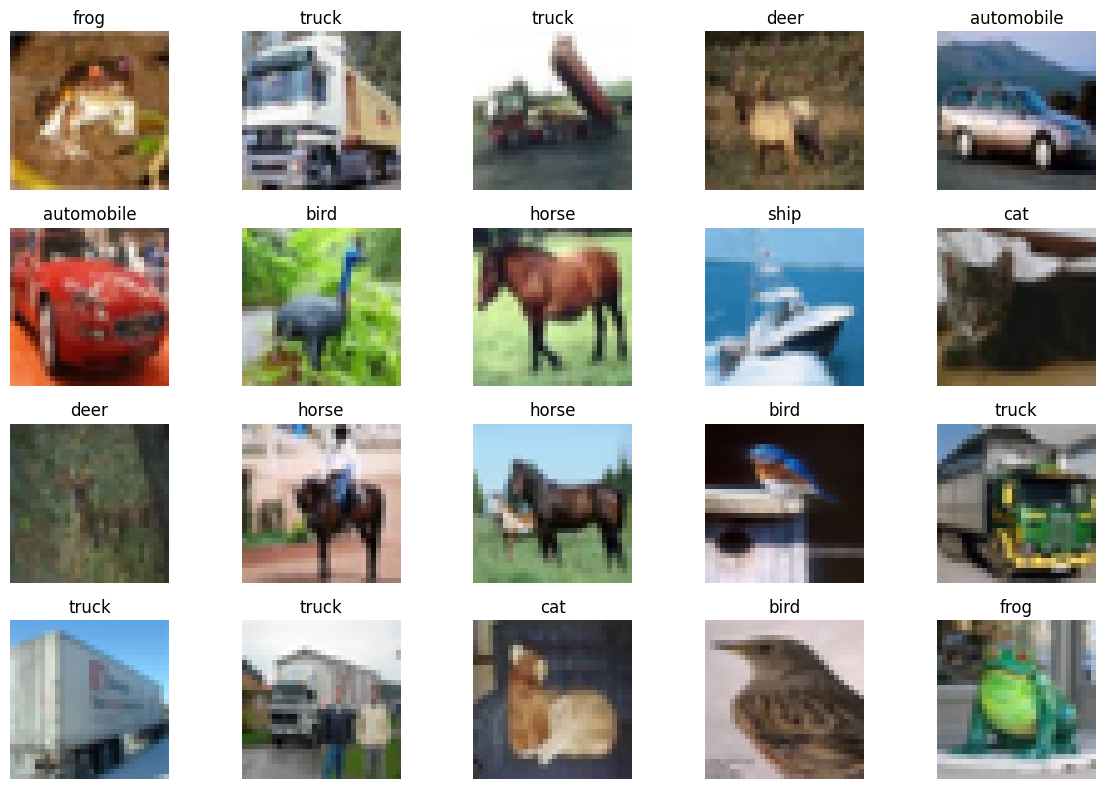

In [5]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Preprocessing completed.")
print("Pixel value range:", x_train.min(), "to", x_train.max())

from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Testing set:", x_test.shape)

Preprocessing completed.
Pixel value range: 0.0 to 1.0
Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Testing set: (10000, 32, 32, 3)


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation created.")

Data augmentation created.


In [8]:
model = models.Sequential([

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 211ms/step - accuracy: 0.3324 - loss: 1.8492 - val_accuracy: 0.4792 - val_loss: 1.4252
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.4386 - loss: 1.5468 - val_accuracy: 0.4398 - val_loss: 1.4980
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 206ms/step - accuracy: 0.4946 - loss: 1.4119 - val_accuracy: 0.5752 - val_loss: 1.1738
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 212ms/step - accuracy: 0.5312 - loss: 1.3173 - val_accuracy: 0.5932 - val_loss: 1.1399
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.5619 - loss: 1.2423 - val_accuracy: 0.6050 - val_loss: 1.1170
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 205ms/step - accuracy: 0.5829 - loss: 1.1876 - val_accuracy: 0.6366 - val_loss: 1.0104
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.6012 - loss: 1.1398 - val_accuracy: 0.6618 - val_loss: 0.9516
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 207ms/step - accuracy: 0.6182 -

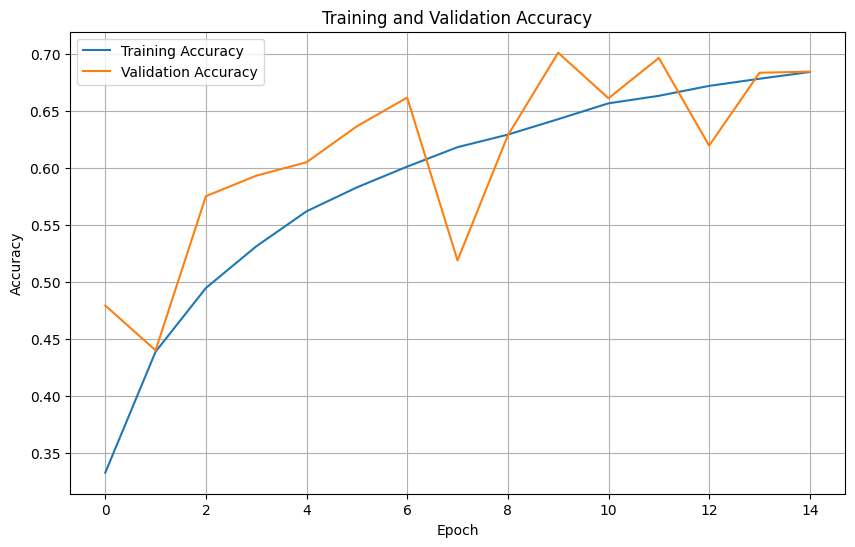

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

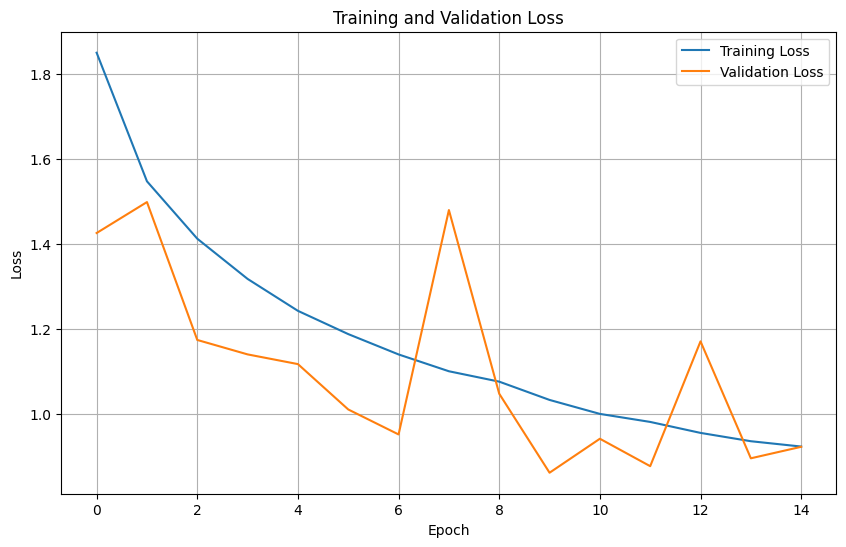

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7086 - loss: 0.8638
Test Loss: 0.8637977242469788
Test Accuracy: 0.7085999846458435


In [14]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Predictions generated successfully.


In [15]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", test_accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.7085999846458435
Precision: 0.7127718329792854
Recall   : 0.7086
F1-Score : 0.7017566829629186


In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.71      0.81      0.75      1000
  automobile       0.82      0.85      0.83      1000
        bird       0.63      0.61      0.62      1000
         cat       0.62      0.39      0.48      1000
        deer       0.66      0.61      0.64      1000
         dog       0.76      0.52      0.62      1000
        frog       0.58      0.90      0.70      1000
       horse       0.78      0.77      0.77      1000
        ship       0.83      0.83      0.83      1000
       truck       0.75      0.80      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



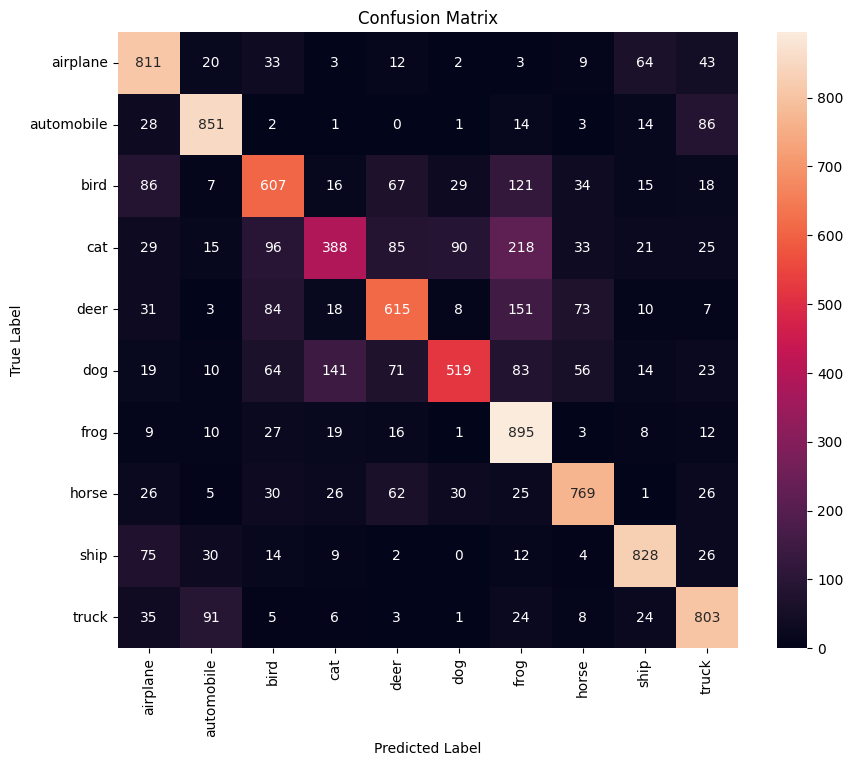

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

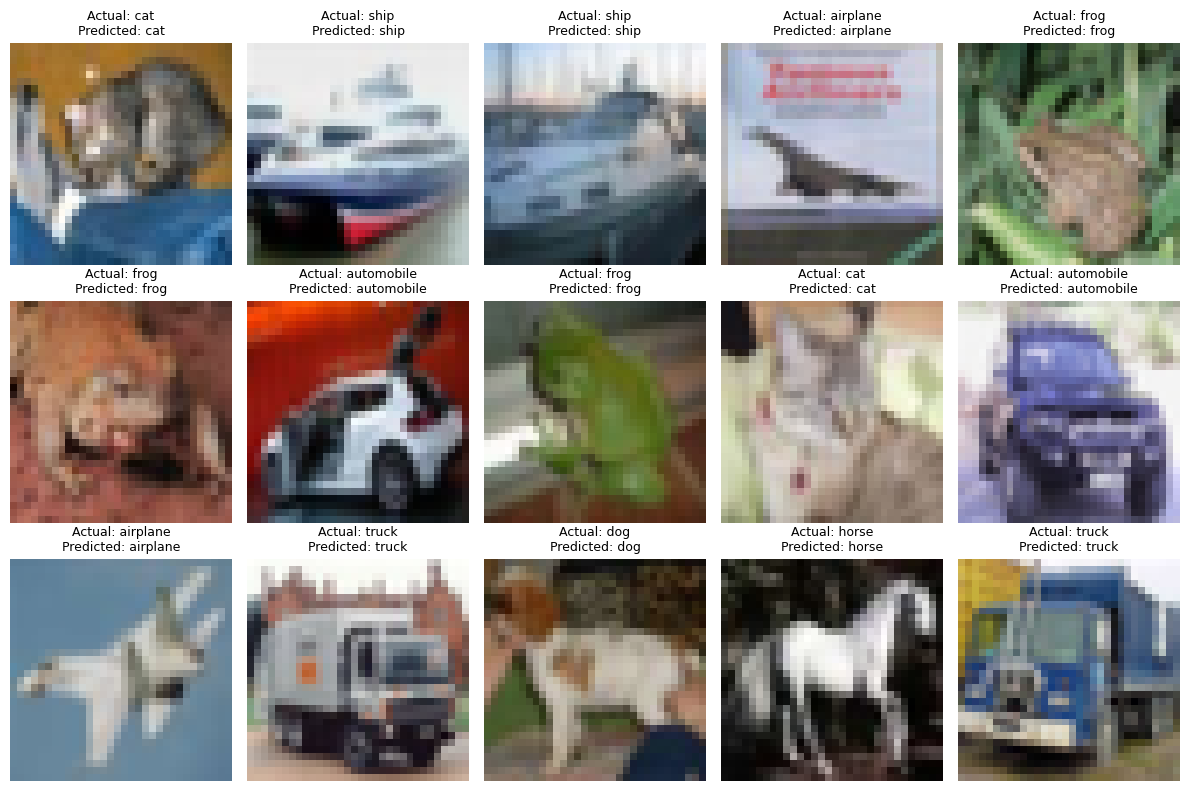

In [18]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model.save("cifar10_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [20]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")

print("=" * 50)

FINAL MODEL RESULTS
Test Accuracy : 0.7086
Precision     : 0.7128
Recall        : 0.7086
F1-Score      : 0.7018


## Results Analysis

The CNN model was trained and tested on the CIFAR-10 dataset. The model achieved a **test accuracy of 70.86%**, with a **precision of 71.28%**, **recall of 70.86%**, and **F1-score of 70.18%**.

### Model Strengths

- The CNN achieved around 71% performance across the main evaluation metrics.
- The model successfully learned useful visual features from the CIFAR-10 images.
- The model performed particularly well on **frog, automobile, ship, truck, and airplane** classes.
- Data augmentation and dropout helped the model generalize to unseen images.

### Model Weaknesses

- The model still incorrectly classified a number of test images.
- It had more difficulty distinguishing between visually similar animal classes.
- The overall accuracy of **70.86%** shows that there is still room for improvement.

### Possible Errors and Misclassifications

The confusion matrix shows that the model had difficulty distinguishing some animal categories. The largest confusion was **cats being classified as frogs**, with **218 cat images** incorrectly predicted as frogs. There was also significant confusion between **deer and frogs**, with **151 deer images** classified as frogs, and between **dogs and cats**, with **141 dog images** classified as cats. The model also confused **trucks with automobiles**, with **91 truck images** predicted as automobiles. These errors may occur because some CIFAR-10 images have similar shapes, colors, and visual features.

### Possible Improvements

The model performance could be improved by:

1. Using a deeper CNN architecture.
2. Improving data augmentation.
3. Performing hyperparameter tuning.
4. Training the model for a suitable number of epochs.
5. Using transfer learning with a pretrained model such as ResNet or MobileNet.
6. Applying additional regularization techniques to reduce overfitting.

### Conclusion

Overall, the CNN achieved a **70.86% test accuracy**, with a **71.28% precision, 70.86% recall, and 70.18% F1-score**. The confusion matrix shows that the model performs well on several classes but has difficulty distinguishing some visually similar animal categories. Further improvements to the CNN architecture, training process, and data augmentation could increase the model's classification performance.
